Saved phase_transition_plot.png

--- i.i.d. non‑uniform experiment ---
Healthy scenario (random labels): R_ratio = 0.9954
Collapse scenario (constant clusters): R_ratio = 0.0011
Saved non_uniform_iid_results.txt


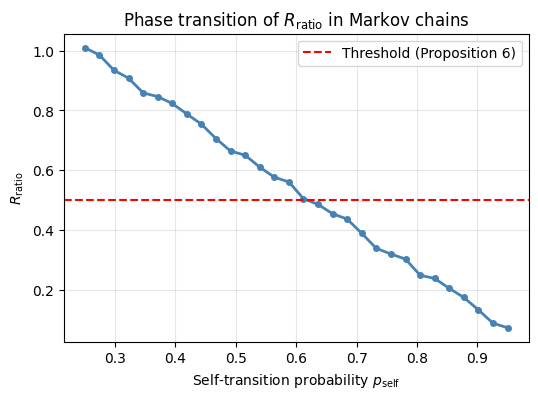

In [1]:
"""
reproduce_scd_results.py
Gera:
 - phase_transition_plot.png (R_ratio vs p_self)
 - non_uniform_iid_results.txt (tabela)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

def expected_runs(N, counts):
    """E[R_null] = 1 + (N^2 - sum(n_k^2)) / N"""
    return 1 + (N**2 - np.sum(counts**2)) / N

def compute_r_ratio(labels):
    N = len(labels)
    _, counts = np.unique(labels, return_counts=True)
    E_R = expected_runs(N, counts)
    R_obs = 1 + np.sum(labels[:-1] != labels[1:])
    return R_obs / E_R

def generate_markov_chain(N, K, p_self):
    states = np.zeros(N, dtype=int)
    states[0] = np.random.randint(0, K)
    for i in range(1, N):
        if np.random.rand() < p_self:
            states[i] = states[i-1]
        else:
            others = [s for s in range(K) if s != states[i-1]]
            states[i] = np.random.choice(others)
    return states

# ----------------------------------------------------------------------
# Experimento 1: Transição de fase
# ----------------------------------------------------------------------
N = 3600
K = 4
p_vals = np.linspace(0.25, 0.95, 30)
r_ratios = []
for p in p_vals:
    labels = generate_markov_chain(N, K, p)
    r_ratios.append(compute_r_ratio(labels))

plt.figure(figsize=(6,4))
plt.plot(p_vals, r_ratios, 'o-', color='steelblue', lw=2, ms=4)
plt.axhline(0.5, color='red', linestyle='--', label='Threshold (Proposition 6)')
plt.xlabel('Self‑transition probability $p_{\\text{self}}$')
plt.ylabel('$R_{\\text{ratio}}$')
plt.title('Phase transition of $R_{\\text{ratio}}$ in Markov chains')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('phase_transition_plot.png', dpi=300, bbox_inches='tight')
print("Saved phase_transition_plot.png")

# ----------------------------------------------------------------------
# Experimento 2: i.i.d. não‑uniforme
# ----------------------------------------------------------------------
np.random.seed(42)
N = 3600
probs = [0.4, 0.3, 0.2, 0.1]
K = len(probs)
labels_iid = np.random.choice(K, size=N, p=probs)
# Cenário saudável (teórico)
counts = np.bincount(labels_iid, minlength=K)
E_R = expected_runs(N, counts)
R_obs = 1 + np.sum(labels_iid[:-1] != labels_iid[1:])
R_ratio_healthy = R_obs / E_R
# Cenário de colapso (simulado: pouquíssimas transições)
labels_collapsed = np.zeros(N, dtype=int)
labels_collapsed[:N//2] = 0
labels_collapsed[N//2:] = 1
counts_coll = np.bincount(labels_collapsed, minlength=K)
E_R_coll = expected_runs(N, counts_coll)
R_obs_coll = 1 + np.sum(labels_collapsed[:-1] != labels_collapsed[1:])
R_ratio_collapsed = R_obs_coll / E_R_coll

print("\n--- i.i.d. non‑uniform experiment ---")
print(f"Healthy scenario (random labels): R_ratio = {R_ratio_healthy:.4f}")
print(f"Collapse scenario (constant clusters): R_ratio = {R_ratio_collapsed:.4f}")
with open('non_uniform_iid_results.txt', 'w') as f:
    f.write(f"Healthy: {R_ratio_healthy:.6f}\nCollapsed: {R_ratio_collapsed:.6f}\n")
print("Saved non_uniform_iid_results.txt")